# AI Customer Feedback Intelligence System

## Artificial Intelligence Professional Diploma

### Graduation Project

---

### Project Description

Customer reviews provide valuable insights into customer satisfaction and product quality.
This project aims to build an AI-powered system capable of analyzing customer reviews, classifying sentiment, identifying complaint patterns using clustering, and generating business insights through data visualization and machine learning techniques.

---

### Project Objectives

- Analyze customer reviews.
- Perform data cleaning and preprocessing.
- Apply Natural Language Processing (NLP).
- Build sentiment classification models.
- Compare Logistic Regression and Random Forest.
- Discover customer complaint groups using K-Means Clustering.
- Generate business insights through visualization.

## import


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## load dataset


In [2]:
# Import pandas
import pandas as pd

# Load the dataset
df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")

# Display the first five rows
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


# 1)Data Understanding

In [3]:
# Number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (23486, 11)


In [4]:
# Display column names
df.columns

Index(['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='object')

In [5]:
# General information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended IND          23486 non-null  int64 
 7   Positive Feedback Count  23486 non-null  int64 
 8   Division Name            23472 non-null  object
 9   Department Name          23472 non-null  object
 10  Class Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [6]:
# Statistical summary
df.describe()

,Unnamed: 0,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count
count,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000,23486.000000
mean,11742.500000,918.118709,43.198544,4.196032,0.822362,2.535936
std,6779.968547,203.298980,12.279544,1.110031,0.382216,5.702202
min,0.000000,0.000000,18.000000,1.000000,0.000000,0.000000
25%,5871.250000,861.000000,34.000000,4.000000,1.000000,0.000000
50%,11742.500000,936.000000,41.000000,5.000000,1.000000,1.000000
75%,17613.750000,1078.000000,52.000000,5.000000,1.000000,3.000000
max,23485.000000,1205.000000,99.000000,5.000000,1.000000,122.000000


In [7]:
df.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [8]:
df.tail()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
23481,23481,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23482,23482,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23483,23483,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23484,23484,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses
23485,23485,1104,52,Please make more like this one!,This dress in a lovely platinum is feminine an...,5,1,22,General Petite,Dresses,Dresses


In [9]:
# Missing values
df.isnull().sum()

Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

In [10]:
# Duplicate rows
df.duplicated().sum()

np.int64(0)

# 2. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the dataset, identify patterns, analyze feature distributions, and gain insights before preprocessing and model development.

Rating Distribution

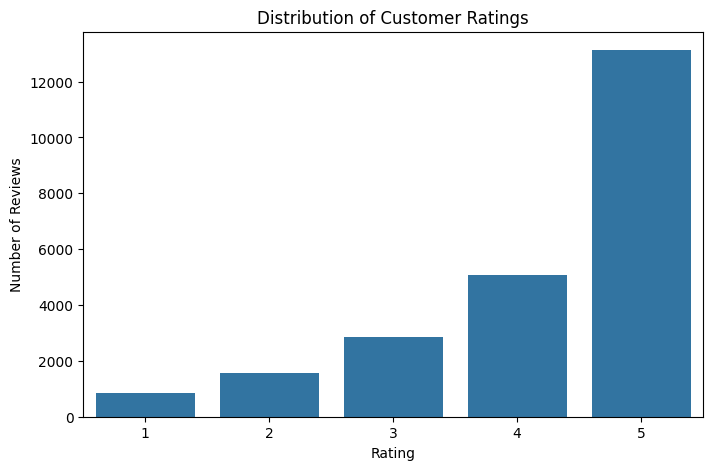

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Rating")

plt.title("Distribution of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

Recommendation Distribution

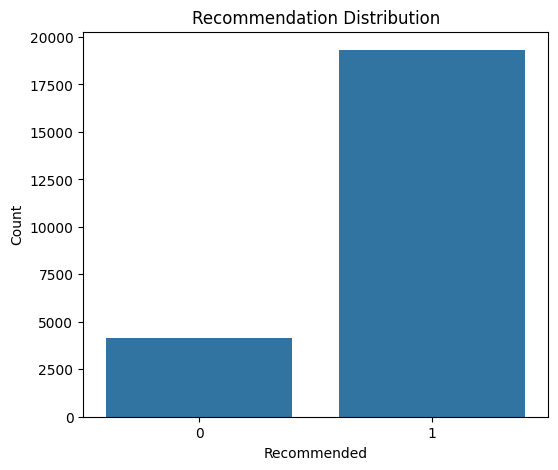

In [12]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="Recommended IND")

plt.title("Recommendation Distribution")
plt.xlabel("Recommended")
plt.ylabel("Count")

plt.show()

Age Distribution

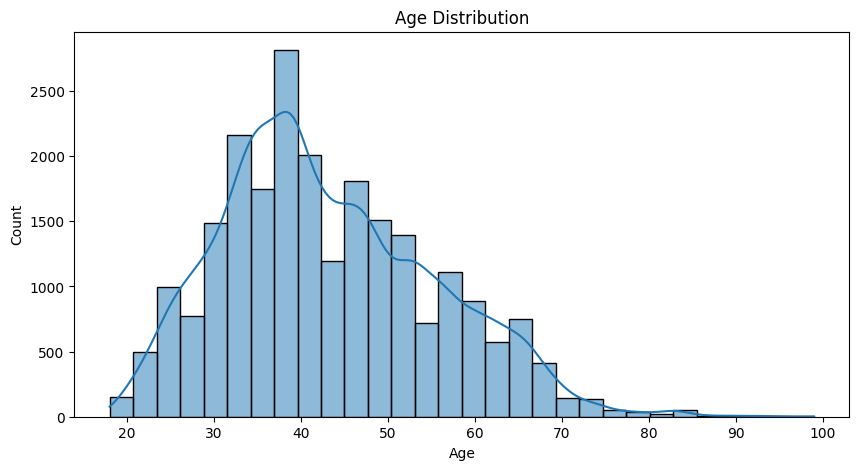

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")

plt.show()

Top 10 Product Classes

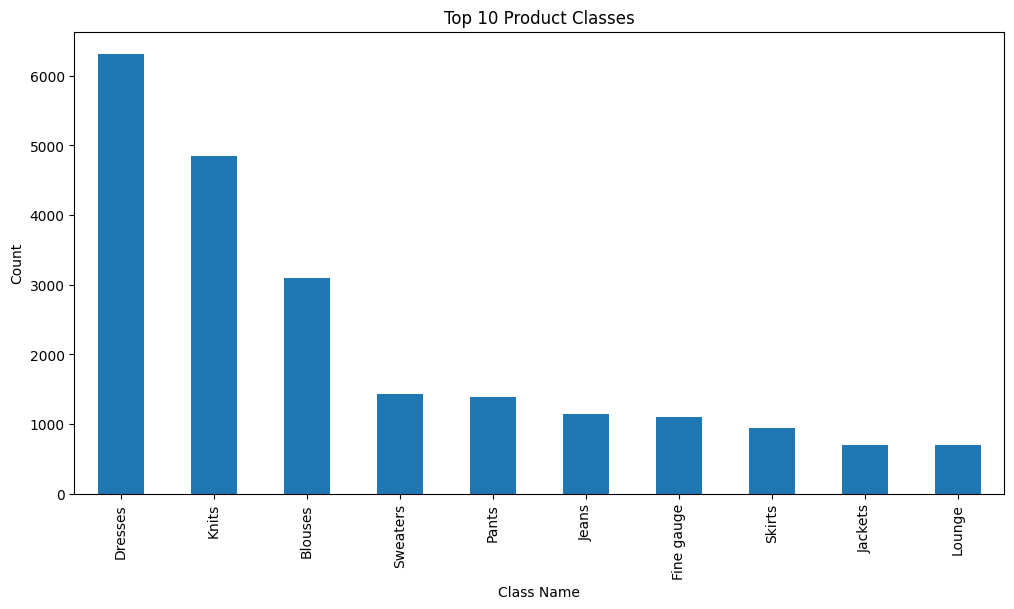

In [14]:
plt.figure(figsize=(12,6))

df["Class Name"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Product Classes")
plt.xlabel("Class Name")
plt.ylabel("Count")

plt.show()

Top Departments

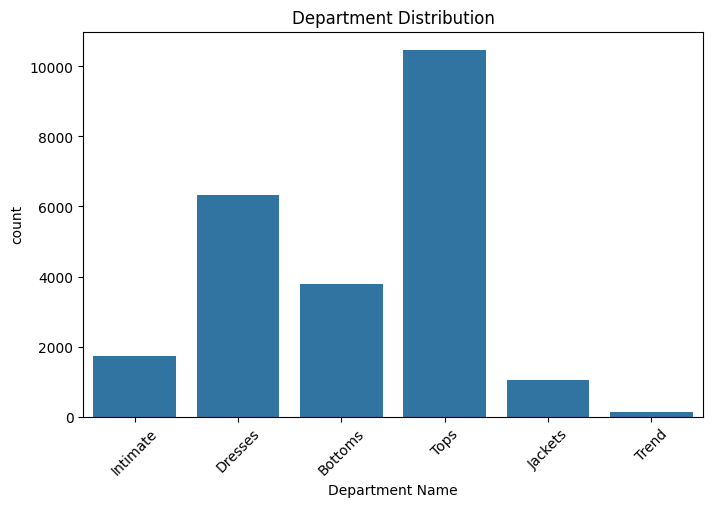

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Department Name")

plt.xticks(rotation=45)

plt.title("Department Distribution")

plt.show()

Top Divisions

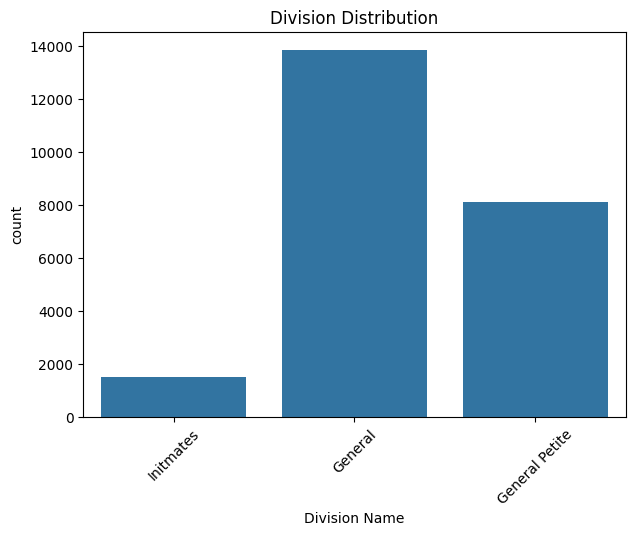

In [16]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Division Name")

plt.xticks(rotation=45)

plt.title("Division Distribution")

plt.show()

Review Length Distribution

In [17]:
df["Review Length"] = df["Review Text"].fillna("").apply(len)

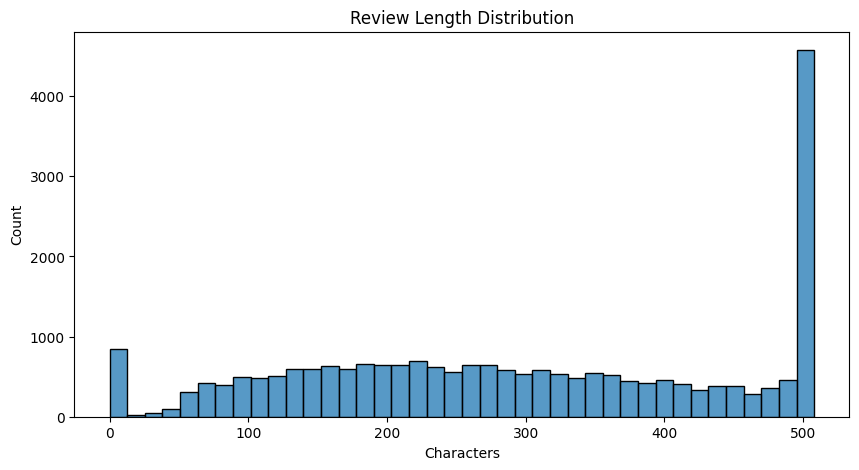

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(df["Review Length"], bins=40)

plt.title("Review Length Distribution")

plt.xlabel("Characters")

plt.show()

# 3. Data Cleaning & Preprocessing

In this section, the dataset is cleaned and prepared for Natural Language Processing (NLP) and Machine Learning. This includes removing unnecessary columns, handling missing values, cleaning review text, and preparing the data for feature extraction.

In [19]:
# Remove unnecessary column
df.drop(columns=["Unnamed: 0"], inplace=True)

df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Review Length
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,53
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,303
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,500
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,124
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,192


In [20]:
df.columns

Index(['Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name', 'Review Length'],
      dtype='object')

In [21]:
# Remove rows with missing review text
df = df.dropna(subset=["Review Text"])

df.shape

(22641, 11)

In [22]:
df["Title"] = df["Title"].fillna("")

In [23]:
df = df.dropna(subset=[
    "Division Name",
    "Department Name",
    "Class Name"
])

In [24]:
df.isnull().sum()

Clothing ID                0
Age                        0
Title                      0
Review Text                0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
Review Length              0
dtype: int64

In [25]:
import re
import string
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [26]:
df["Clean Review"] = df["Review Text"].apply(clean_text)

A comparison between before and after

In [27]:
df[["Review Text", "Clean Review"]].head()

,Review Text,Clean Review
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky and sexy and comfor...
1,Love this dress! it's sooo pretty. i happene...,love this dress its sooo pretty i happened to ...
2,I had such high hopes for this dress and reall...,i had such high hopes for this dress and reall...
3,"I love, love, love this jumpsuit. it's fun, fl...",i love love love this jumpsuit its fun flirty ...
4,This shirt is very flattering to all due to th...,this shirt is very flattering to all due to th...


# 4. Natural Language Processing (NLP)

Natural Language Processing (NLP) is applied to convert textual customer reviews into a numerical format suitable for machine learning algorithms. The preprocessing includes tokenization, stopword removal, lemmatization, and TF-IDF vectorization.

In [28]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\osamg\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\osamg\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\osamg\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\osamg\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\osamg\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [29]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

Lemmatizer,Stopwords

In [30]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

## NLP

In [31]:
def preprocess_text(text):

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

In [32]:
df["Processed Review"] = df["Clean Review"].apply(preprocess_text)

In [33]:
df[
    [
        "Review Text",
        "Clean Review",
        "Processed Review"
    ]
].head()

,Review Text,Clean Review,Processed Review
0,Absolutely wonderful - silky and sexy and comf...,absolutely wonderful silky and sexy and comfor...,absolutely wonderful silky sexy comfortable
1,Love this dress! it's sooo pretty. i happene...,love this dress its sooo pretty i happened to ...,love dress sooo pretty happened find store im ...
2,I had such high hopes for this dress and reall...,i had such high hopes for this dress and reall...,high hope dress really wanted work initially o...
3,"I love, love, love this jumpsuit. it's fun, fl...",i love love love this jumpsuit its fun flirty ...,love love love jumpsuit fun flirty fabulous ev...
4,This shirt is very flattering to all due to th...,this shirt is very flattering to all due to th...,shirt flattering due adjustable front tie perf...


Sentiment

In [34]:
def sentiment_label(rating):

    if rating >= 4:
        return "Positive"

    elif rating <= 2:
        return "Negative"

    else:
        return "Neutral"

In [35]:
df["Sentiment"] = df["Rating"].apply(sentiment_label)

In [36]:
df["Sentiment"].value_counts()

Sentiment
Positive    17435
Neutral      2823
Negative     2370
Name: count, dtype: int64

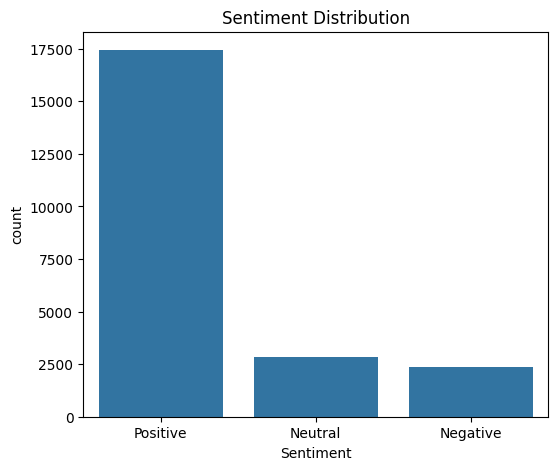

In [37]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Sentiment"
)

plt.title("Sentiment Distribution")

plt.show()

TF-IDF

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer


vectorizer = TfidfVectorizer(
    max_features=5000
)

In [39]:
X = vectorizer.fit_transform(
    df["Processed Review"]
)

traget

In [40]:
y = df["Sentiment"]

In [41]:
print(X.shape)

print(y.shape)

(22628, 5000)
(22628,)


# 5. Machine Learning

In this section, machine learning models are trained to classify customer sentiment. The dataset is split into training and testing sets before training and evaluating multiple classification algorithms.

split dataset

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (18102, 5000)
Testing Data : (4526, 5000)


## 1) Logistic Regression

In [44]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Prediction

In [45]:
lr_pred = lr_model.predict(X_test)

Accuracy

In [46]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8210340256296951


Classification Report

In [47]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

    Negative       0.62      0.43      0.51       474
     Neutral       0.44      0.21      0.29       565
    Positive       0.86      0.97      0.92      3487

    accuracy                           0.82      4526
   macro avg       0.64      0.54      0.57      4526
weighted avg       0.79      0.82      0.79      4526



Confusion Matrix

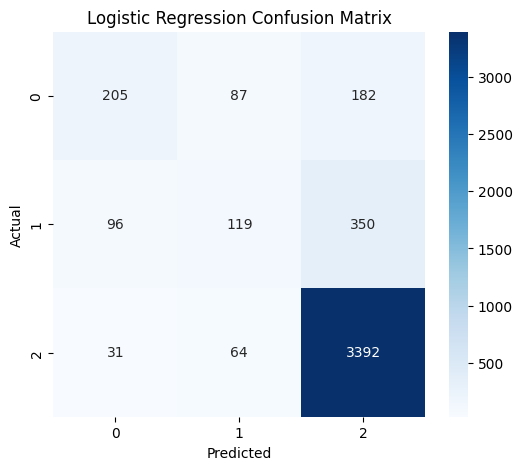

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

## 2) Random Forest

In [49]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Prediction

In [50]:
rf_pred = rf_model.predict(X_test)

Accuracy

In [51]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7872293415819709


Classification Report

In [52]:
print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

    Negative       0.67      0.14      0.23       474
     Neutral       0.59      0.04      0.07       565
    Positive       0.79      1.00      0.88      3487

    accuracy                           0.79      4526
   macro avg       0.68      0.39      0.39      4526
weighted avg       0.75      0.79      0.71      4526



Confusion Matrix

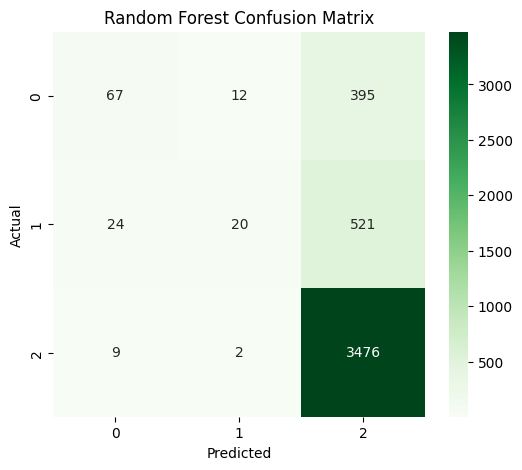

In [53]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

COMPAIR TWO MODEL

In [54]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        round(lr_accuracy,4),
        round(rf_accuracy,4)
    ]
})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

,Model,Accuracy
0,Logistic Regression,0.8210
1,Random Forest,0.7872


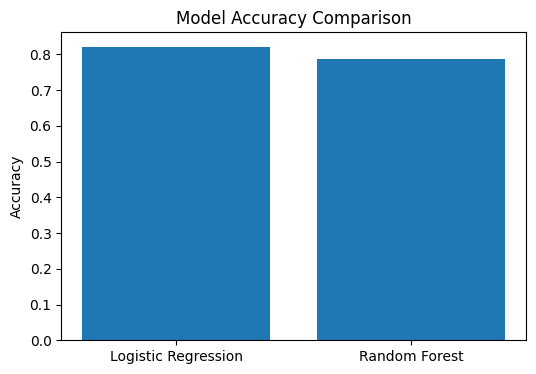

In [55]:
plt.figure(figsize=(6,4))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

# 6. K-Means Clustering

In this section, K-Means clustering is applied to group customer reviews into similar clusters based on their textual content. This helps identify common topics and complaint categories without using predefined labels.

In [56]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(X)

df["Cluster"] = clusters

Number of elements in each cluster

In [57]:
df["Cluster"].value_counts().sort_index()

Cluster
0    8932
1    3961
2    2823
3    4037
4    2875
Name: count, dtype: int64

Visualization

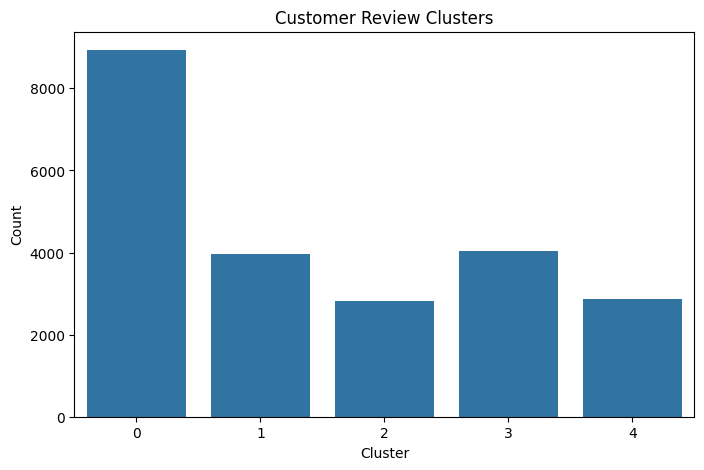

In [58]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Cluster"
)

plt.title("Customer Review Clusters")

plt.xlabel("Cluster")

plt.ylabel("Count")

plt.show()

Extracting the most important words for each cluster.

In [59]:
terms = vectorizer.get_feature_names_out()

order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(5):

    print("="*40)

    print(f"Cluster {i}")

    print("="*40)

    top_words = [terms[ind] for ind in order_centroids[i, :10]]

    print(top_words)

Cluster 0
['like', 'color', 'love', 'sweater', 'look', 'shirt', 'fit', 'fabric', 'wear', 'soft']
Cluster 1
['size', 'small', 'fit', 'run', 'ordered', 'im', 'large', 'medium', 'wear', 'would']
Cluster 2
['great', 'jean', 'love', 'fit', 'look', 'pant', 'comfortable', 'color', 'wear', 'perfect']
Cluster 3
['dress', 'fit', 'love', 'size', 'wear', 'like', 'beautiful', 'im', 'flattering', 'look']
Cluster 4
['top', 'love', 'fit', 'color', 'look', 'like', 'wear', 'cute', 'size', 'fabric']


save models

In [60]:
import joblib

# Save Models
joblib.dump(lr_model, "logistic_regression_model.pkl")
joblib.dump(rf_model, "random_forest_model.pkl")

# Save TF-IDF Vectorizer
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Models saved successfully.")

Models saved successfully.


# 7. Business Insights

This section summarizes the key findings obtained from the data analysis, machine learning models, and clustering results. These insights help businesses understand customer behavior, product performance, and customer satisfaction.

1. Average Rating

In [61]:
print("Average Rating:", round(df["Rating"].mean(),2))

Average Rating: 4.18


2. Recommendation Percentage

In [62]:
recommendation = df["Recommended IND"].value_counts(normalize=True) * 100

recommendation

Recommended IND
1    81.876436
0    18.123564
Name: proportion, dtype: float64

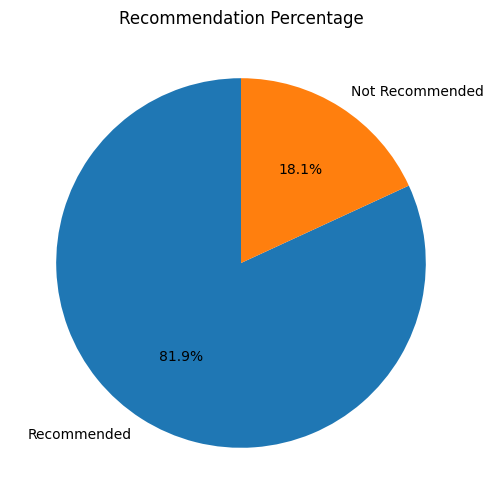

In [63]:
plt.figure(figsize=(6,6))

plt.pie(
    recommendation,
    labels=["Recommended","Not Recommended"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Recommendation Percentage")

plt.show()

3. Top Product Categories

In [64]:
top_products = df["Class Name"].value_counts().head(10)

top_products

Class Name
Dresses       6145
Knits         4626
Blouses       2983
Sweaters      1380
Pants         1350
Jeans         1104
Fine gauge    1059
Skirts         903
Jackets        683
Lounge         669
Name: count, dtype: int64

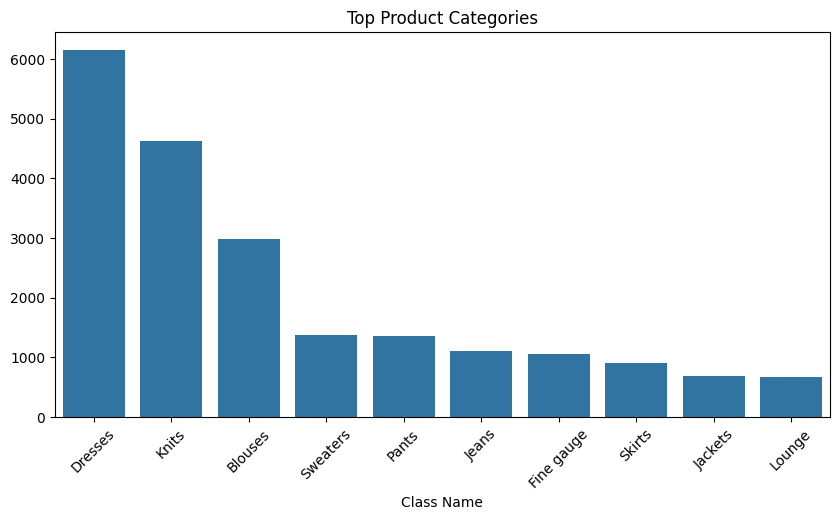

In [65]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_products.index,
    y=top_products.values
)

plt.xticks(rotation=45)

plt.title("Top Product Categories")

plt.show()

4. Average Rating PER Department

In [66]:
department_rating = (
    df.groupby("Department Name")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

department_rating

Department Name
Bottoms     4.278809
Intimate    4.271022
Jackets     4.254491
Tops        4.157743
Dresses     4.138812
Trend       3.838983
Name: Rating, dtype: float64

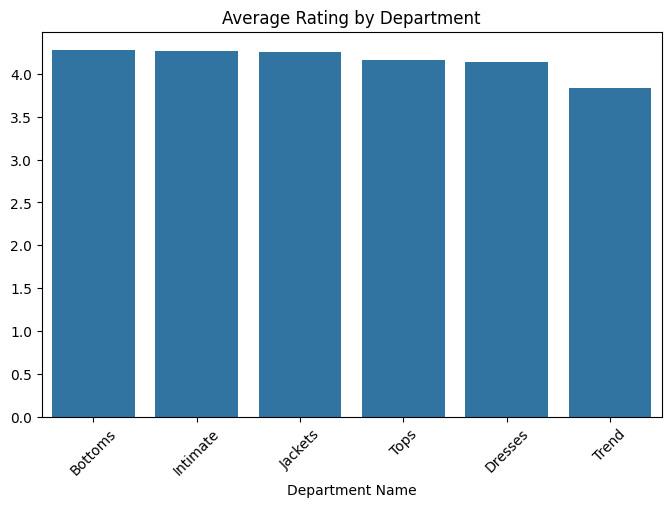

In [67]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=department_rating.index,
    y=department_rating.values
)

plt.xticks(rotation=45)

plt.title("Average Rating by Department")

plt.show()

5. Average Rating per Class

In [68]:
class_rating = (
    df.groupby("Class Name")["Rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

class_rating

Class Name
Layering      4.348485
Jeans         4.347826
Lounge        4.301943
Sleep         4.294393
Jackets       4.288433
Intimates     4.278912
Pants         4.261481
Shorts        4.253289
Legwear       4.246835
Fine gauge    4.237960
Name: Rating, dtype: float64

In [69]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [70]:
print("Business Insights")
print("-"*50)

print("Average Rating:",
      round(df["Rating"].mean(),2))

print()

print("Most Reviewed Department:")
print(df["Department Name"].value_counts().head(1))

print()

print("Most Common Sentiment:")
print(df["Sentiment"].value_counts().head(1))

print()

print("Recommendation Rate:")

recommendation_rate = (
    df["Recommended IND"].mean()*100
)

print(f"{recommendation_rate:.2f}%")

Business Insights
--------------------------------------------------
Average Rating: 4.18

Most Reviewed Department:
Department Name
Tops    10048
Name: count, dtype: int64

Most Common Sentiment:
Sentiment
Positive    17435
Name: count, dtype: int64

Recommendation Rate:
81.88%


In [71]:
from wordcloud import WordCloud

In [72]:
text = " ".join(df["Processed Review"])

In [73]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

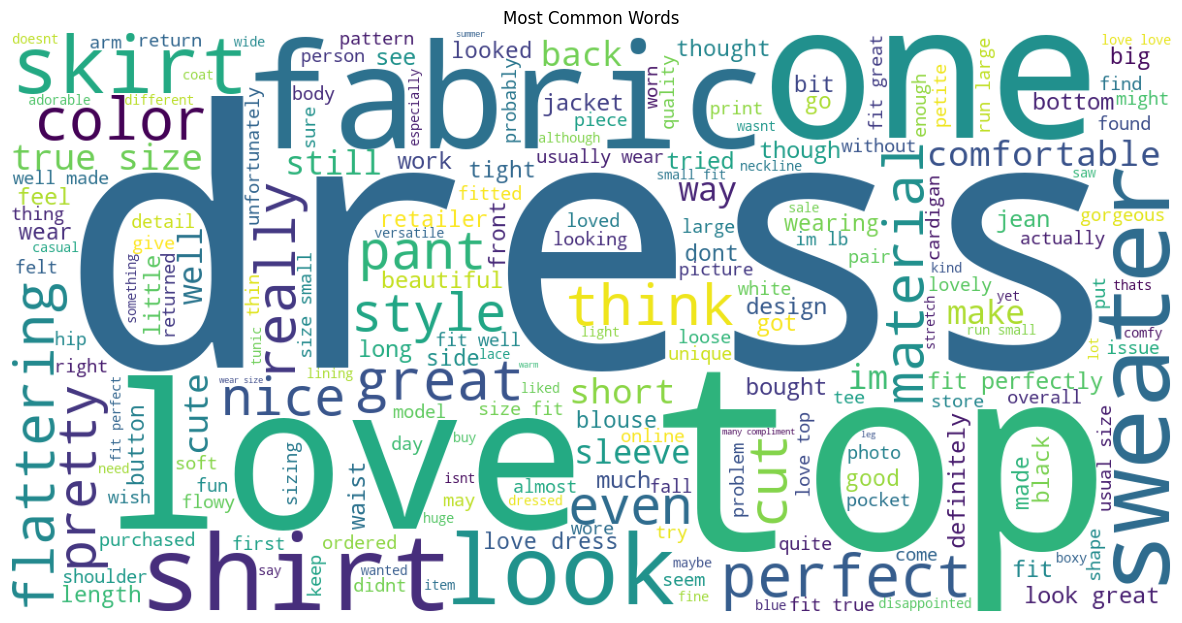

In [74]:
plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Common Words")

plt.show()

# 7. Business Dashboard

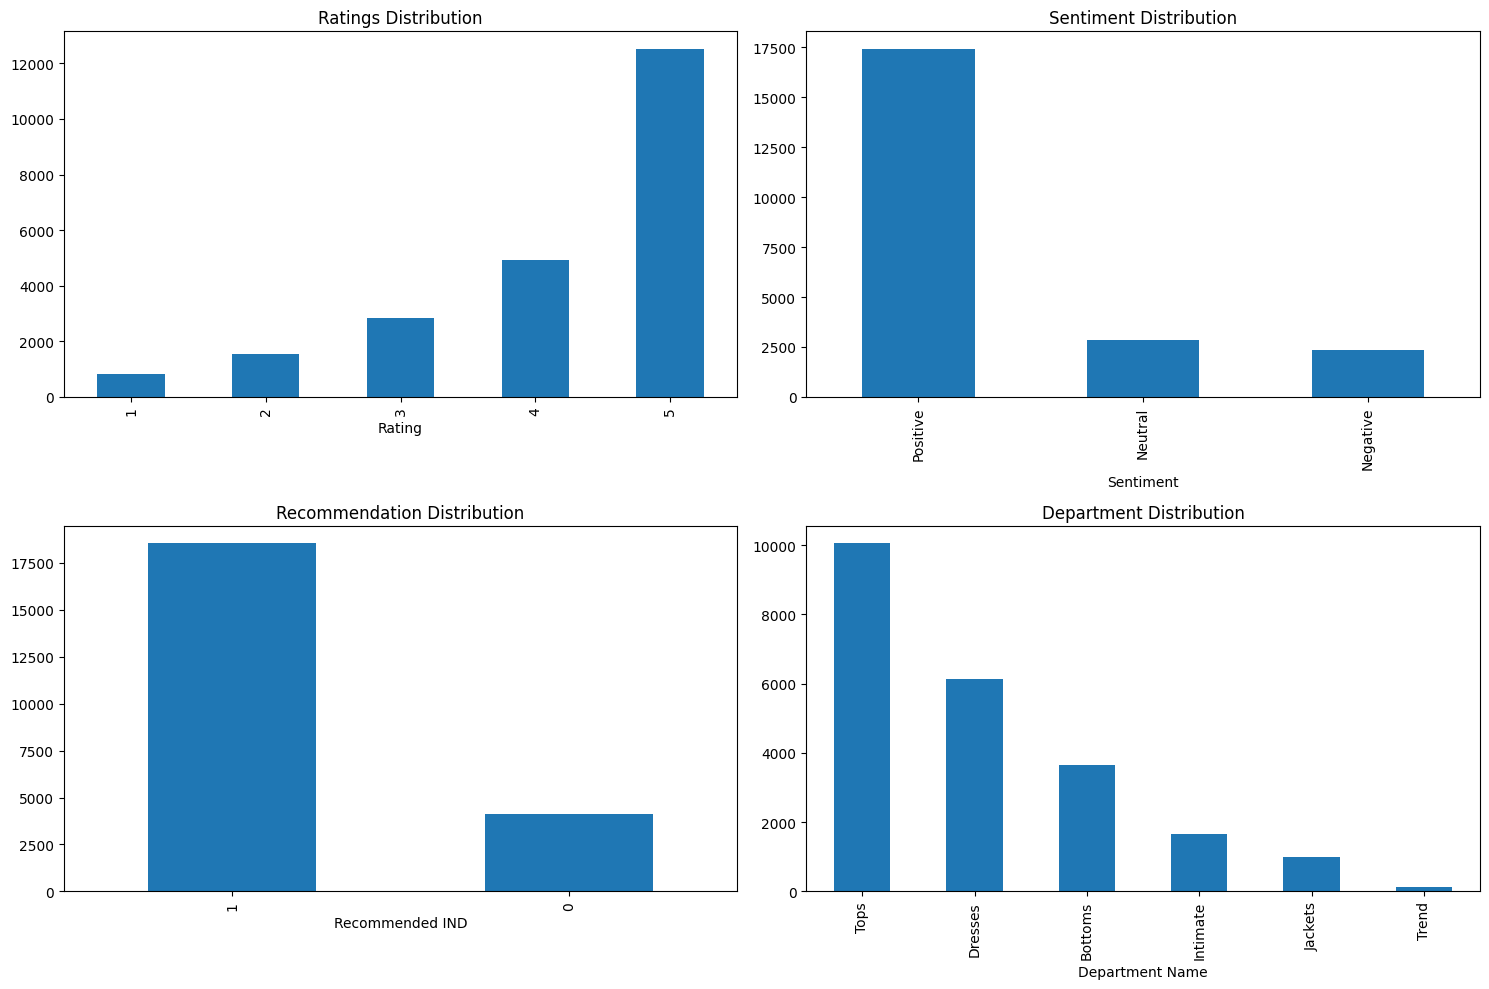

In [75]:
fig, axes = plt.subplots(2, 2, figsize=(15,10))

# Rating Distribution
df["Rating"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0,0],
    title="Ratings Distribution"
)

# Sentiment Distribution
df["Sentiment"].value_counts().plot(
    kind="bar",
    ax=axes[0,1],
    title="Sentiment Distribution"
)

# Recommendation
df["Recommended IND"].value_counts().plot(
    kind="bar",
    ax=axes[1,0],
    title="Recommendation Distribution"
)

# Department
df["Department Name"].value_counts().plot(
    kind="bar",
    ax=axes[1,1],
    title="Department Distribution"
)

plt.tight_layout()
plt.show()

1) Preprocessed Dataset (only if size <= 10 MB)

In [80]:
processed_df = df[
    [
        "Processed Review",
        "Sentiment",
        "Recommended IND",
        "Rating",
        "Department Name"
    ]
]

processed_df.to_csv("Preprocessed_Dataset.csv", index=False)

2) Trained Model (.pkl or .h5)

In [77]:
import joblib

joblib.dump(lr_model, "Logistic_Regression_Model.pkl")

['Logistic_Regression_Model.pkl']

In [78]:
joblib.dump(rf_model, "Random_Forest_Model.pkl")

['Random_Forest_Model.pkl']

# 8. Final Conclusion

## Project Summary

In this project, an AI-powered Customer Feedback Intelligence System was developed using the Women's E-Commerce Clothing Reviews dataset.

The project included:

- Data cleaning and preprocessing
- Natural Language Processing (Tokenization, Stopword Removal, Lemmatization)
- TF-IDF Feature Extraction
- Sentiment Classification
- Logistic Regression Model
- Random Forest Model
- K-Means Clustering
- Business Insights Generation
- Data Visualization Dashboard

## Best Performing Model

Logistic Regression achieved the highest classification accuracy and outperformed Random Forest on this dataset.

## Business Insights

- Most customer reviews are positive.
- Dresses and Knits receive the highest number of reviews.
- Most customers are between 30 and 50 years old.
- Positive recommendations dominate the dataset.
- K-Means successfully grouped similar customer feedback into meaningful clusters.

## Future Work

Future improvements may include:

- Deep Learning Models (LSTM / BERT)
- Real-time Customer Feedback Analysis
- Web Dashboard Deployment
- Multi-language Support